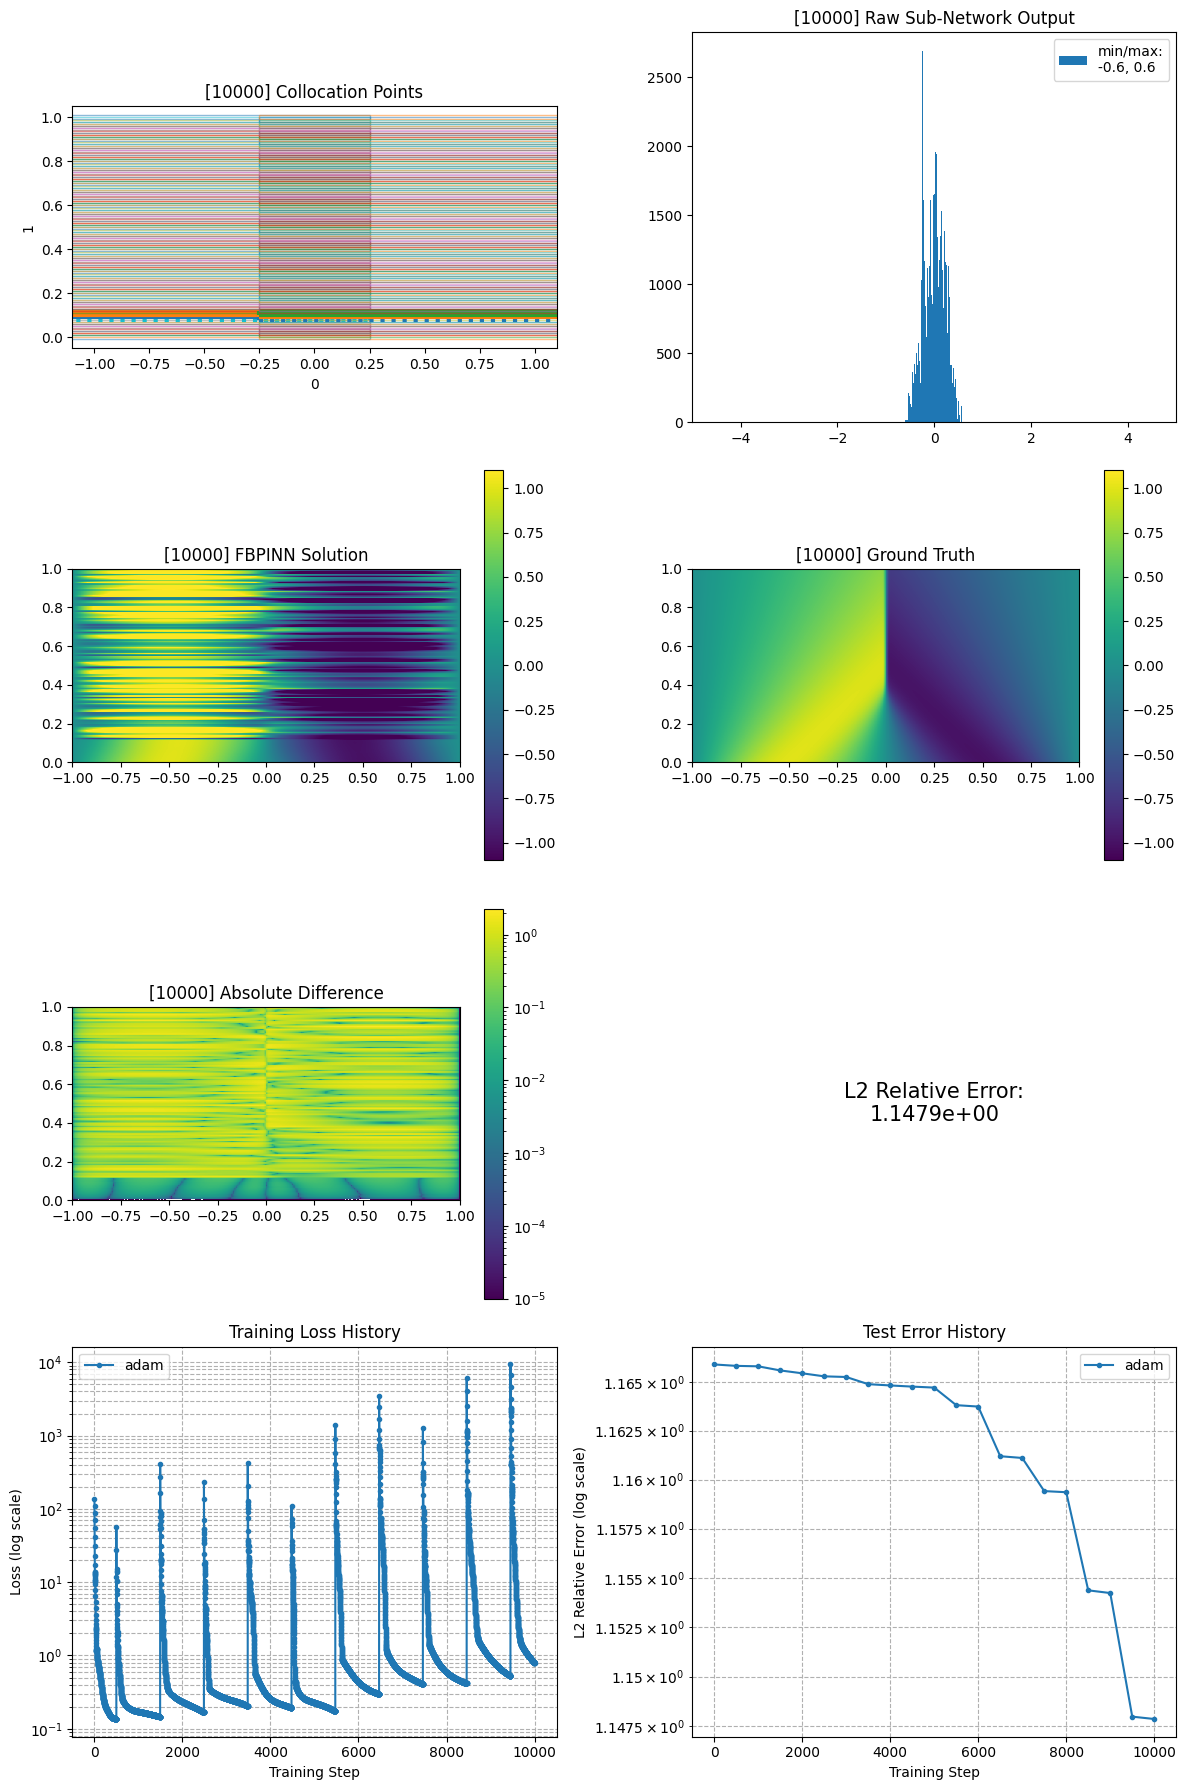

[INFO] 2025-07-01 06:51:52 - [i: 10448/100000] Updating active inputs..
[INFO] 2025-07-01 06:51:52 - [i: 10448/100000] Average number of points/dimension in active subdomains: 9.80
[INFO] 2025-07-01 06:51:53 - [i: 10448/100000] Updating active inputs done (0.63 s)
[INFO] 2025-07-01 06:51:53 - [i: 10448/100000] Initialising new state.
[INFO] 2025-07-01 06:51:53 - [i: 10448/100000] Compiling update step..
[INFO] 2025-07-01 06:51:53 - [i: 10448/100000] Compiling done (0.00 s)
[INFO] 2025-07-01 06:51:54 - [i: 11000/100000] loss: 1.40581 rate: 9.4 elapsed: 0.03 hr test
[INFO] 2025-07-01 06:51:55 - [i: 11443/100000] Updating active inputs..
[INFO] 2025-07-01 06:51:55 - [i: 11443/100000] Average number of points/dimension in active subdomains: 9.85
[INFO] 2025-07-01 06:51:58 - [i: 11443/100000] Updating active inputs done (2.69 s)
[INFO] 2025-07-01 06:51:58 - [i: 11443/100000] Initialising new state.
[INFO] 2025-07-01 06:51:58 - [i: 11443/100000] Compiling update step..
[INFO] 2025-07-01 06:5

KeyboardInterrupt: 

In [17]:
import numpy as np

from fbpinns.domains import RectangularDomainND
from fbpinns.problems import BurgersEquation2D
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.networks import FCN
from fbpinns.schedulers import LineSchedulerRectangularND
from fbpinns.constants import Constants, get_subdomain_ws
from fbpinns.trainers import FBPINNTrainer

import optax

from fbpinns.optimisers import adaptive_newton_method

subdomain_xs=[np.array([-0.6, 0.6]), np.linspace(0,1,101)]
subdomain_ws=[np.array([1.7, 1.7]), np.array([1.9 / 101,] * len(subdomain_xs[1]))]

c = Constants(
    domain=RectangularDomainND,
    domain_init_kwargs = dict(
        xmin=np.array([-1,0.]),
        xmax=np.array([1.,1.])
        ),
    problem=BurgersEquation2D,
    problem_init_kwargs = dict(),
    decomposition=RectangularDecompositionND,
    decomposition_init_kwargs=dict(
        subdomain_xs=subdomain_xs,
        subdomain_ws=subdomain_ws,
        unnorm=(0.,3.),
    ),
    network=FCN,
    network_init_kwargs = dict(
        layer_sizes = (2, 8, 8, 8, 8, 1),
    ),
    scheduler = LineSchedulerRectangularND,
    scheduler_kwargs = dict(
        point=[0.], iaxis=0,
    ),
    
    sampler="sobol",
    
    ns=((128,64),),
    n_test=(256,128),
    clear_output=True,
    
    test_freq=1000 / 2,
    
    optimiser_schedule=[
        (optax.adam, 100000, dict(
            learning_rate=3e-3
        )),
    ],
)

run = FBPINNTrainer(c)
all_params = run.train()